**Sistema Predictivo de Deserción Universitaria y Perfilado de Estudiantes en Riesgo**


In [ ]:
# Librerías
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Preparación de datos y reducción de dimensionalidad
from sklearn.manifold import TSNE
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de Clasificación
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Métricas de Evaluación
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Descripción del dataset

* El conjunto de datos utilizado corresponde a información académica, demográfica y socioeconómica de estudiantes universitarios, con el objetivo de analizar factores asociados al éxito académico y al abandono estudiantil.

* El dataset contiene variables relacionadas con:
  * características personales del estudiante,
  * antecedentes educativos,
  * situación económica,
  * información familiar,
  * y desempeño académico durante los primeros semestres.

* La variable objetivo del análisis es target (u objetivo), que clasifica a los estudiantes en tres categorías:
  * `Graduate`: estudiantes graduados,
  * `Dropout`: estudiantes que abandonaron sus estudios,
  * `Enrolled`: estudiantes que continúan cursando.

* Entre las variables incluidas se encuentran:
  * variables demográficas como edad de inscripción, género y nacionalidad,
  * variables socioeconómicas como becas, situación de deuda y matrícula al día,
  * variables familiares relacionadas con ocupación y nivel educativo de los padres,
  * y variables académicas como materias matriculadas, evaluaciones realizadas y materias aprobadas en el primer y segundo semestre.

El dataset posee variables tanto numéricas como categóricas codificadas numéricamente. Algunas de estas variables representan categorías discretas mediante códigos enteros, por lo que requieren un análisis interpretativo adecuado.

# Carga de Dataset

In [ ]:
# Cargamos la base de datos a utilizar
file_path = '/content/drive/MyDrive/Ciencia de Datos/Proyecto/data.csv'

try:
    data = pd.read_csv(file_path, sep=';', decimal=',')
    print("Base de datos cargada exitosamente.")
    display(data.head())
except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta especificada: {file_path}")
    print("Por favor, verifica la ruta y asegúrate de que el archivo existe en tu Google Drive.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Base de datos cargada exitosamente.


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666666666666666,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,Graduate


# Limpieza y Preprocesamiento

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Marital status                                  4424 non-null   int64 
 1   Application mode                                4424 non-null   int64 
 2   Application order                               4424 non-null   int64 
 3   Course                                          4424 non-null   int64 
 4   Daytime/evening attendance	                     4424 non-null   int64 
 5   Previous qualification                          4424 non-null   int64 
 6   Previous qualification (grade)                  4424 non-null   object
 7   Nacionality                                     4424 non-null   int64 
 8   Mother's qualification                          4424 non-null   int64 
 9   Father's qualification                          4424

**`Target` es el objetivo conceptual (Dropout, Enrolled, Graduate)**

Hay 8 variables de tipo `object`.

`Previous qualification (grade)` , `Admission grade` ,  

`Curricular units 1st sem (grade)` y `Curricular units 2nd sem (grade)` son notas.


`Unemployment rate`,` Inflation rate` y `GDP` son indicadores macroeconómicos.

*Detecté que variables continuas como las notas y las tasas macroeconómicas fueron importadas como texto (object). Debemos corregirlo para poder calcular estadísticas descriptivas y entrenar los modelos.*

In [ ]:
#Traducimos al espanol las columnas
nuevos_nombres = {
    'marital_status': 'estado_civil',
    'application_mode': 'modo_solicitud',
    'application_order': 'orden_solicitud',
    'course': 'carrera',
    'daytime_evening_attendance': 'turno_asistencia',
    'previous_qualification': 'titulacion_previa',
    'previous_qualification_grade': 'nota_titulacion_previa',
    'nacionality': 'nacionalidad',
    "mother's_qualification": 'titulacion_madre',
    "father's_qualification": 'titulacion_padre',
    "mother's_occupation": 'ocupacion_madre',
    "father's_occupation": 'ocupacion_padre',
    'admission_grade': 'nota_admision',
    'displaced': 'desplazado',
    'educational_special_needs': 'necesidades_especiales',
    'debtor': 'deudor',
    'tuition_fees_up_to_date': 'matricula_al_dia',
    'gender': 'genero',
    'scholarship_holder': 'becado',
    'age_at_enrollment': 'edad_inscripcion',
    'international': 'internacional',
    'curricular_units_1st_sem_credited': 'sem1_acreditadas',
    'curricular_units_1st_sem_enrolled': 'sem1_matriculadas',
    'curricular_units_1st_sem_evaluations': 'sem1_evaluaciones',
    'curricular_units_1st_sem_approved': 'sem1_aprobadas',
    'curricular_units_1st_sem_grade': 'sem1_nota',
    'curricular_units_1st_sem_without_evaluations': 'sem1_sin_evaluar',
    'curricular_units_2nd_sem_credited': 'sem2_acreditadas',
    'curricular_units_2nd_sem_enrolled': 'sem2_matriculadas',
    'curricular_units_2nd_sem_evaluations': 'sem2_evaluaciones',
    'curricular_units_2nd_sem_approved': 'sem2_aprobadas',
    'curricular_units_2nd_sem_grade': 'sem2_nota',
    'curricular_units_2nd_sem_without_evaluations': 'sem2_sin_evaluar',
    'unemployment_rate': 'tasa_desempleo',
    'inflation_rate': 'tasa_inflacion',
    'gdp': 'pib',
    'target': 'objetivo'}

In [ ]:
#Copiamos el dataframe original y trabajaremos con la copia
df = data.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False) # Agregamos esto para limpiar 'daytime/evening'
    .str.replace("\t", "", regex=False) # Quitamos tabulaciones ocultas
)
#Aplicamos la traducción
df.rename(columns=nuevos_nombres, inplace=True)

#Corrección de tipos: de texto ('object') a decimales ('float64')
columnas_a_numericas = [
    'nota_titulacion_previa', 'nota_admision', 'sem1_nota', 'sem2_nota',
    'tasa_desempleo', 'tasa_inflacion', 'pib']

for col in columnas_a_numericas:
    df[col] = df[col].astype(float)

# Análisis Exploratorio de Datos (EDA)

Estructura general del Dataset

In [ ]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(4424, 37)


El dataset cuenta con **4424 registros** (estudiantes) y **37 variables**.

In [ ]:
print("Información general:")
df.info()

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   estado_civil            4424 non-null   int64  
 1   modo_solicitud          4424 non-null   int64  
 2   orden_solicitud         4424 non-null   int64  
 3   carrera                 4424 non-null   int64  
 4   turno_asistencia        4424 non-null   int64  
 5   titulacion_previa       4424 non-null   int64  
 6   nota_titulacion_previa  4424 non-null   float64
 7   nacionalidad            4424 non-null   int64  
 8   titulacion_madre        4424 non-null   int64  
 9   titulacion_padre        4424 non-null   int64  
 10  ocupacion_madre         4424 non-null   int64  
 11  ocupacion_padre         4424 non-null   int64  
 12  nota_admision           4424 non-null   float64
 13  desplazado              4424 non-null   int64  
 14  necesidades_especia

Con esto podemos comprobar que el dataset quedó perfectamente preparado en la etapa previa de limpieza. Nos damos cuenta de tres cosas muy importantes:


1.   Cero valores nulos
2.   Ya convertimos las notas y los datos de la economía a números decimales (float64).

3.   Tenemos **7 variables numéricas reales** (float64), **una de tipo texto **(object) que es nuestro objetivo (el target a predecir), y** el resto son números enteros** (int64). Cabe destacar que la mayoría de estos enteros funcionan en realidad como etiquetas o categorías codificadas.

In [ ]:
print("Estadísticas descriptivas:")
display(df.describe())

Estadísticas descriptivas:


,estado_civil,modo_solicitud,orden_solicitud,carrera,turno_asistencia,titulacion_previa,nota_titulacion_previa,nacionalidad,titulacion_madre,titulacion_padre,...,sem1_sin_evaluar,sem2_acreditadas,sem2_matriculadas,sem2_evaluaciones,sem2_aprobadas,sem2_nota,sem2_sin_evaluar,tasa_desempleo,tasa_inflacion,pib
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Al mirar la tabla de estadísticas descriptivas, tenemos que hacer una separación muy importante entre lo que son números reales y lo que son códigos:



*   **En las variables categóricas**: Datos como el promedio (mean) de la columna `carrera` o `estado_civil` no tienen un sentido matemático real. Esas variables las vamos a analizar contando sus frecuencias
*   En las **variables numéricas reales**: Acá sí encontramos datos interesantes para conocer el perfil de los alumnos.


In [ ]:
print("Valores faltantes:")
display(df.isnull().sum().sort_values(ascending=False))

Valores faltantes:


,0
estado_civil,0
modo_solicitud,0
orden_solicitud,0
carrera,0
turno_asistencia,0
titulacion_previa,0
nota_titulacion_previa,0
nacionalidad,0
titulacion_madre,0
titulacion_padre,0


In [ ]:
print("Duplicados:")
print(df.duplicated().sum())

Duplicados:
0


*Al confirmar que no tenemos ni un solo valor nulo ni filas duplicadas, podemos asegurar que la base de datos está completamente limpia y es confiable.*

## Distribución de la variable objetivo

In [ ]:
conteo = df['objetivo'].value_counts()
porcentajes = df['objetivo'].value_counts(normalize=True) * 100

print("Distribución de la Variable Objetivo (Target):")
print(conteo)

Distribución de la Variable Objetivo (Target):
objetivo
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


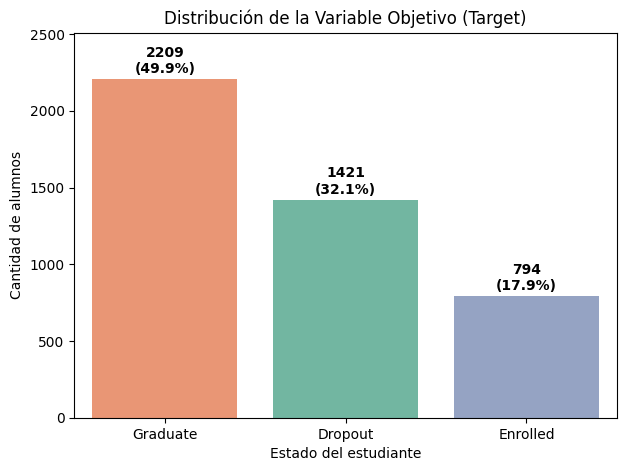

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="objetivo",
    hue="objetivo",
    palette="Set2",
    order=conteo.index
)
# poner el número exacto y el porcentaje arriba de cada barra
for i, valor in enumerate(conteo):
    pct = porcentajes.iloc[i].round(1)
    plt.text(i, valor + 40, f"{valor}\n({pct}%)",
             ha='center', fontweight='bold')

plt.title("Distribución de la Variable Objetivo (Target)")
plt.xlabel("Estado del estudiante")
plt.ylabel("Cantidad de alumnos")
plt.ylim(0, max(conteo) + 300) # Le damos espacio arriba para que entren los textos
plt.show()

*Al graficar la variable objetivo, se observa un desbalance moderado de clases, entonces **no podremos confiar ciegamente en la métrica de Accuracy** (Exactitud)*

*Un modelo básico podría predecir siempre la clase mayoritaria y parecer preciso sin serlo. Este gráfico justifica que para evaluar los modelos usaremos métricas más estrictas como el **F1-Score**, **Presicion** y **la matriz de confusión**, asegurando que el sistema sea realmente eficaz para detectar a los estudiantes en riesgo de abandono.*

## Mapa de Calor de Correlaciones

Antes de mirar variable por variable, graficamos este mapa de calor para ver el panorama completo de los datos.

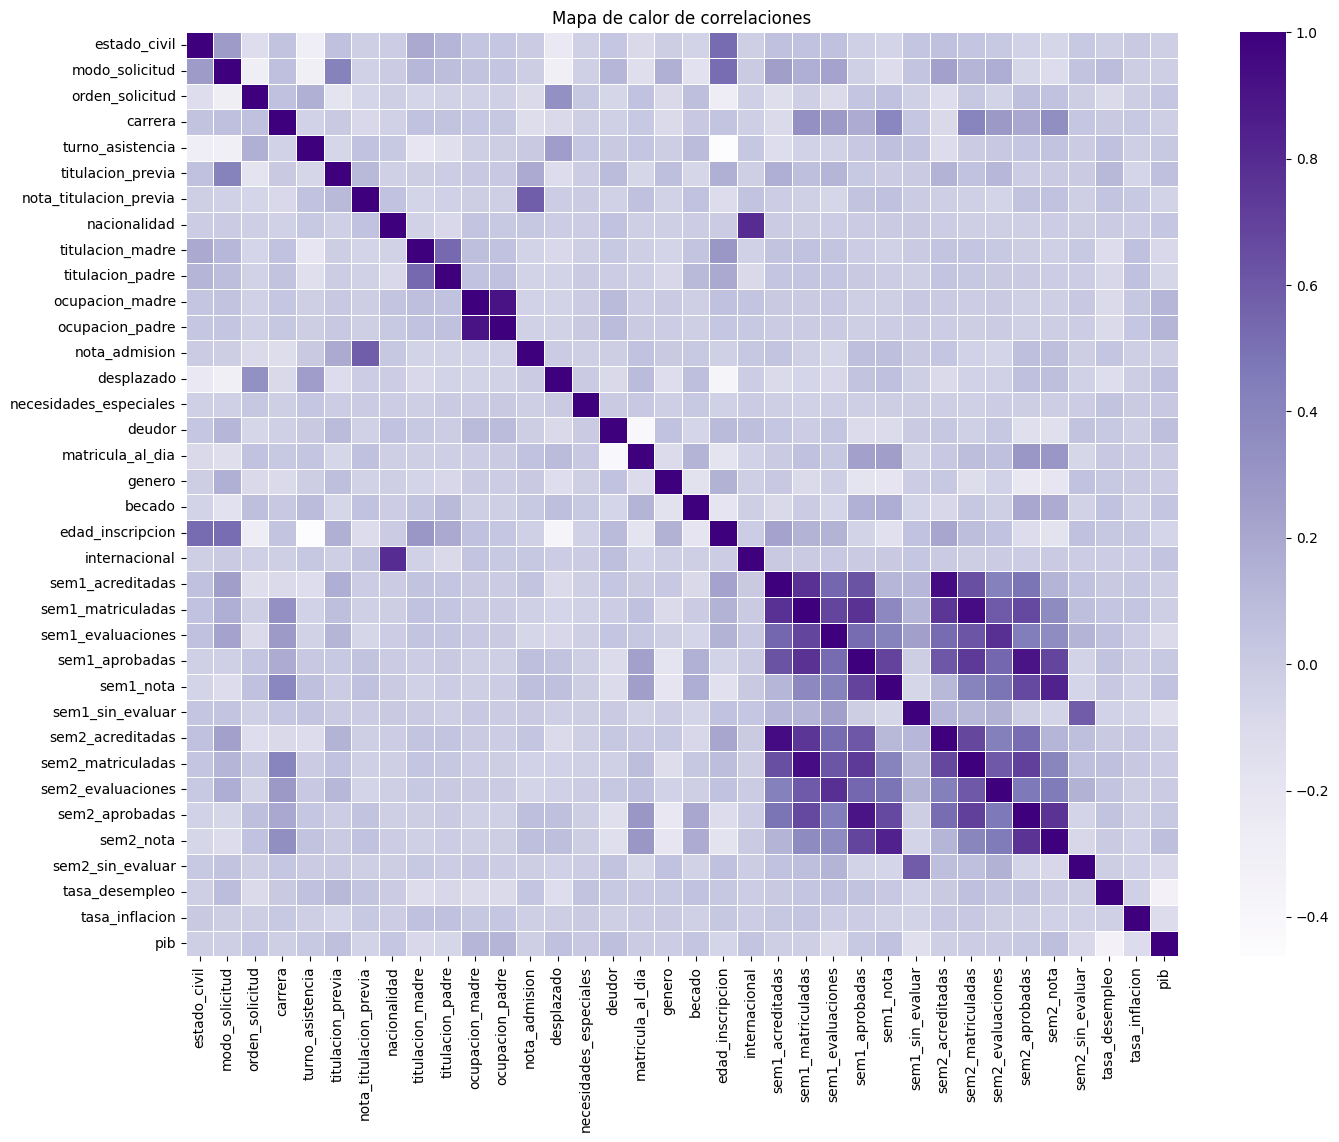

In [ ]:
# Variables
target = "objetivo"

variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns

# Sacamos binarias para algunos gráficos
variables_no_binarias = [
    col for col in variables_numericas
    if df[col].nunique() > 2
]

#  MAPA DE CALOR DE CORRELACIONES
plt.figure(figsize=(16, 12))
corr = df[variables_numericas].corr()

sns.heatmap(corr,cmap="Purples",annot=False,linewidths=0.5)
plt.title("Mapa de calor de correlaciones")
plt.show()

 Acá descubrimos que el rendimiento académico del primer año está relacionados.

## ¿Qué factores influyen más en el abandono universitario?


**Variables de Ingreso a la Universidad**

Acá vamos a analizar las características con las que el estudiante llega a la universidad.

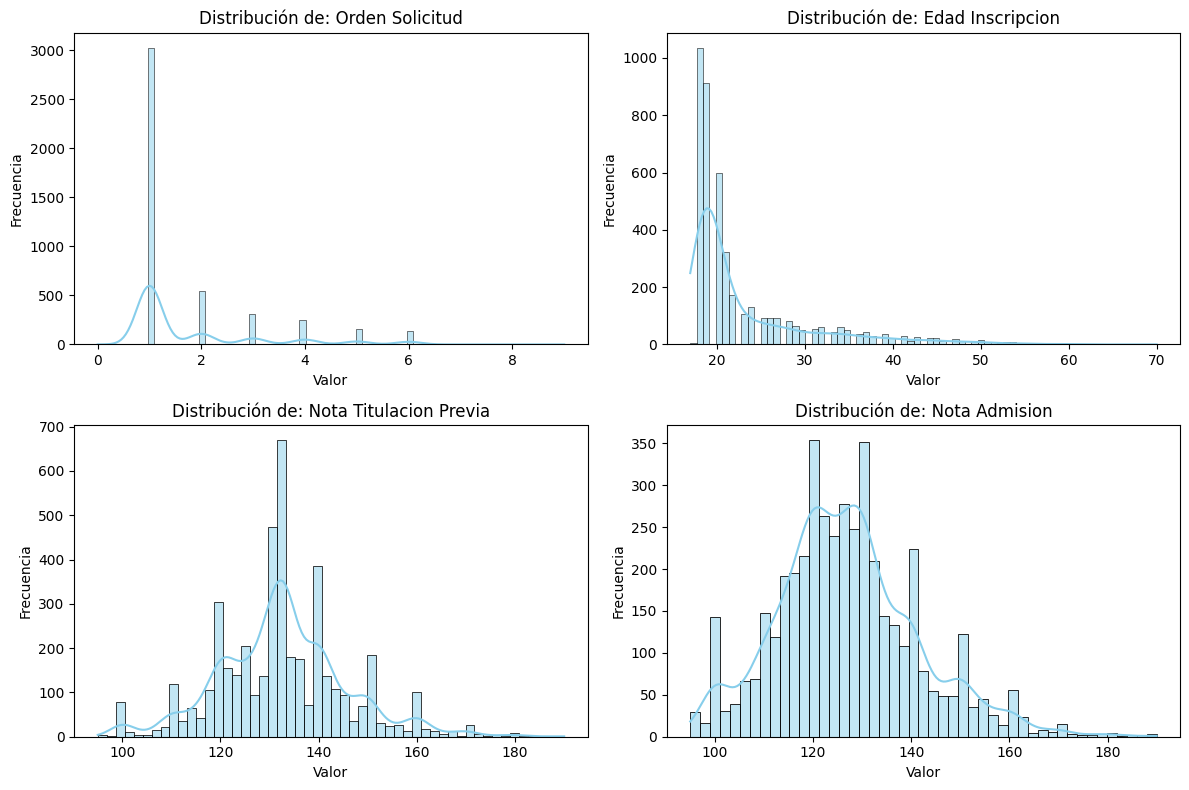

In [ ]:
# Seleccionamos las variables de ingreso
vars_ingreso = ['orden_solicitud', 'edad_inscripcion', 'nota_titulacion_previa', 'nota_admision']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_ingreso):
    # kde=True dibuja la línea de tendencia de la distribución
    sns.histplot(data=df, x=col, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(f"Distribución de: {col.replace('_', ' ').title()}")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

*Lo primero que hicimos fue analizar cómo llega el estudiante a la universidad. Descubrimos que el perfil del ingresante promedio es un joven de entre 18 y 22 años, que viene con notas medias del secundario (entre 120 y 140 puntos) y que entra muy motivado, ya que para la gran mayoría esta carrera era su primera opción.*

### ¿Aprobar pocas materias en el arranque es sinónimo de abandono?

Hipotesis : *Los estudiantes con menor cantidad de materias aprobadas en primer año tienen mayor probabilidad de abandono.*

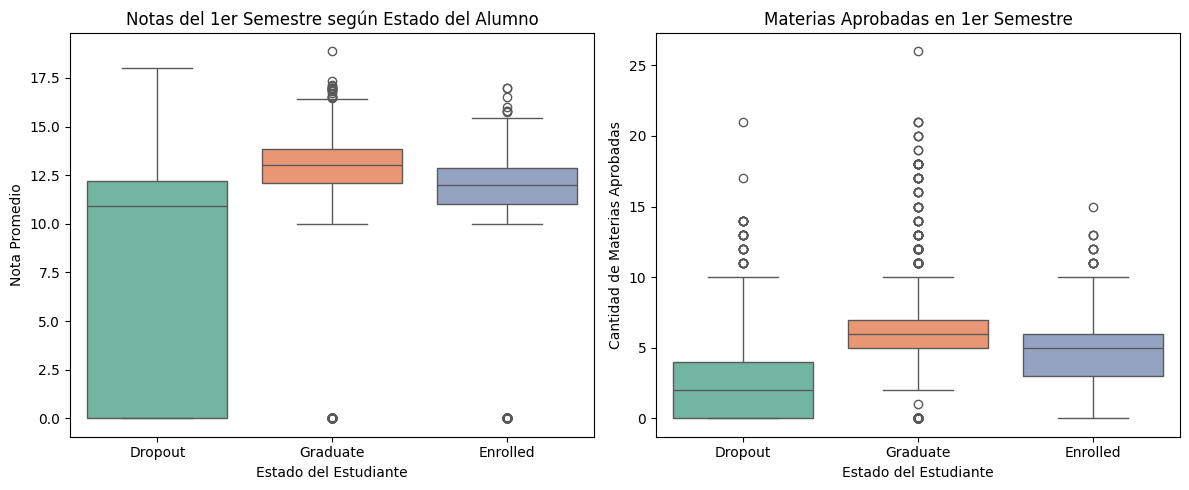

In [ ]:
plt.figure(figsize=(12, 5))

# Gráfico para Notas del Semestre 1
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='objetivo', y='sem1_nota',hue='objetivo', palette='Set2')
plt.title('Notas del 1er Semestre según Estado del Alumno')
plt.xlabel('Estado del Estudiante')
plt.ylabel('Nota Promedio')

# Gráfico para Materias Aprobadas en Semestre 1
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='objetivo', y='sem1_aprobadas', hue='objetivo',palette='Set2')
plt.title('Materias Aprobadas en 1er Semestre')
plt.xlabel('Estado del Estudiante')
plt.ylabel('Cantidad de Materias Aprobadas')

plt.tight_layout()
plt.show()

*Los estudiantes que lograron graduarse tuvieron, en general, un muy buen comienzo: aprobaron alrededor de 6 materias y obtuvieron promedios cercanos a 13 puntos. En cambio, quienes abandonaron la carrera tuvieron un rendimiento mucho más bajo. La mayoría aprobó 2 materias o menos, e incluso varios terminaron el semestre sin aprobar ninguna.*

*En general, los estudiantes que tienen pocas materias aprobadas y promedios bajos durante el primer semestre son los que tienen más probabilidades de abandonar la universidad más adelante.*

### ¿Las variables económicas impactan en la permanencia?

Hipotesis : *Tener beca reduce la deserción, las crisis económicas la aumentan y el estado de pago de matrícula es altamente predictivo.*

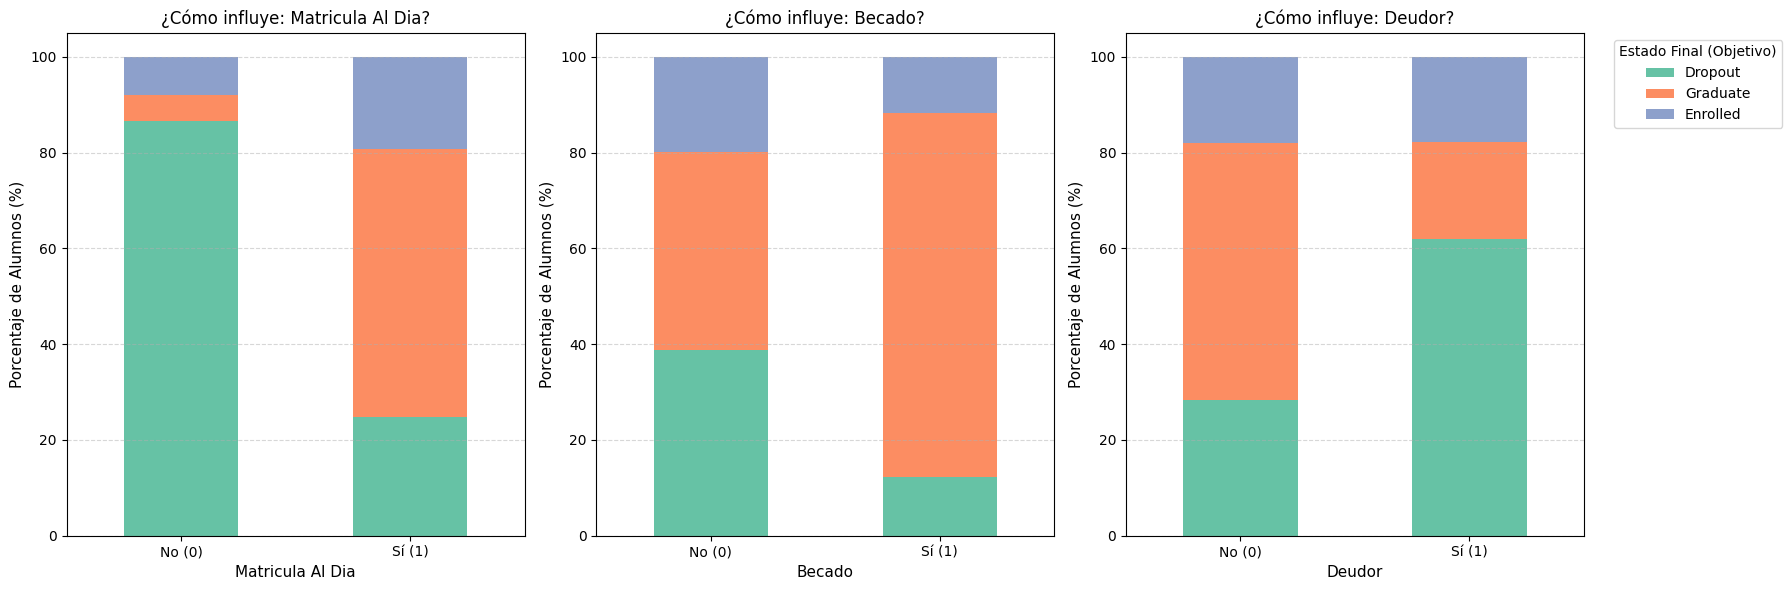

In [ ]:
vars_financieras = ['matricula_al_dia', 'becado', 'deudor']

colores_set2 = {
    'Dropout': '#66c2a5',
    'Graduate': '#fc8d62',
    'Enrolled': '#8da0cb'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(vars_financieras):
    # Transformamos los datos a porcentajes por cada fila (No / Sí)
    tabla_porcentual = pd.crosstab(df[col], df['objetivo'], normalize='index') * 100

    categorias_presentes = [cat for cat in colores_set2.keys() if cat in tabla_porcentual.columns]
    tabla_porcentual = tabla_porcentual[categorias_presentes]
    lista_colores = [colores_set2[cat] for cat in categorias_presentes]

    # Graficamos las barras apiladas en su respectivo subgráfico (ax=axes[i])
    tabla_porcentual.plot(kind='bar', stacked=True, ax=axes[i], color=lista_colores)

    # Configuración de títulos y etiquetas
    axes[i].set_title(f"¿Cómo influye: {col.replace('_', ' ').title()}?")
    axes[i].set_xlabel(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_ylabel("Porcentaje de Alumnos (%)", fontsize=11)
    axes[i].set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5) # Una leve grilla horizontal ayuda a leer porcentajes

    # Dejamos la leyenda solo en el último gráfico para que no se repita y sature el espacio
    if i == 2:
        axes[i].legend(title='Estado Final (Objetivo)', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

*La situación económica influye notablemente en la permanencia de los estudiantes. Quienes presentan deudas o problemas con el pago de la matrícula tienen una mayor tendencia a abandonar la carrera, mientras que los estudiantes becados muestran mayores tasas de permanencia y graduación.*

### El Entorno Familiar: Educación y Ocupación de los Padres

*Hipótesis: Los estudiantes cuyos padres (madre o padre) tienen títulos de educación superior muestran tasas de graduación más altas y menor abandono.*

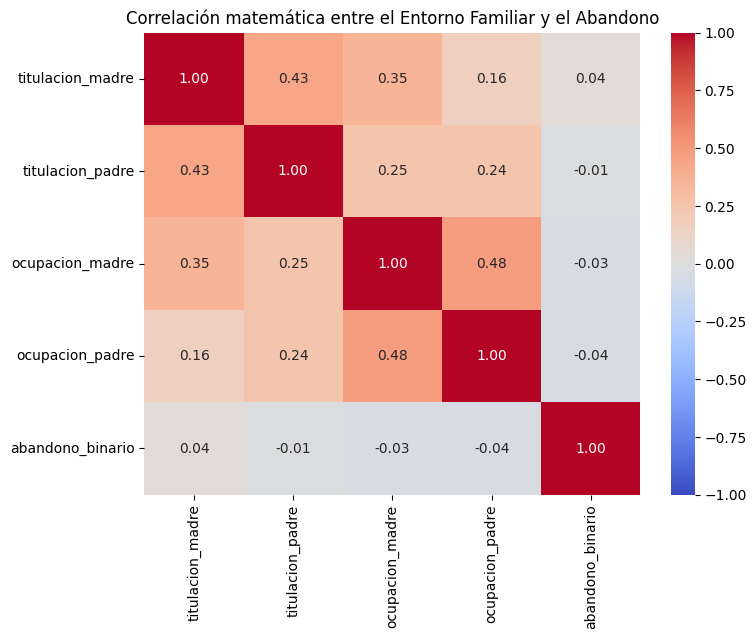

In [ ]:
# Creación de variable numérica de abandono (1 si abandonó, 0 si sigue o se graduó)
df['abandono_binario'] = (df['objetivo'] == 'Dropout').astype(int)

# Seleccionamos las familiares y nuestra nueva variable de abandono
columnas_analisis = ['titulacion_madre', 'titulacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'abandono_binario']

# Calculamos la correlación de Spearman
matriz_corr = df[columnas_analisis].corr(method='spearman')

# Graficamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación matemática entre el Entorno Familiar y el Abandono')
plt.show()

df.drop(columns=['abandono_binario'], inplace=True)

*El éxito o el abandono del estudiante no está determinado por su origen familiar.*

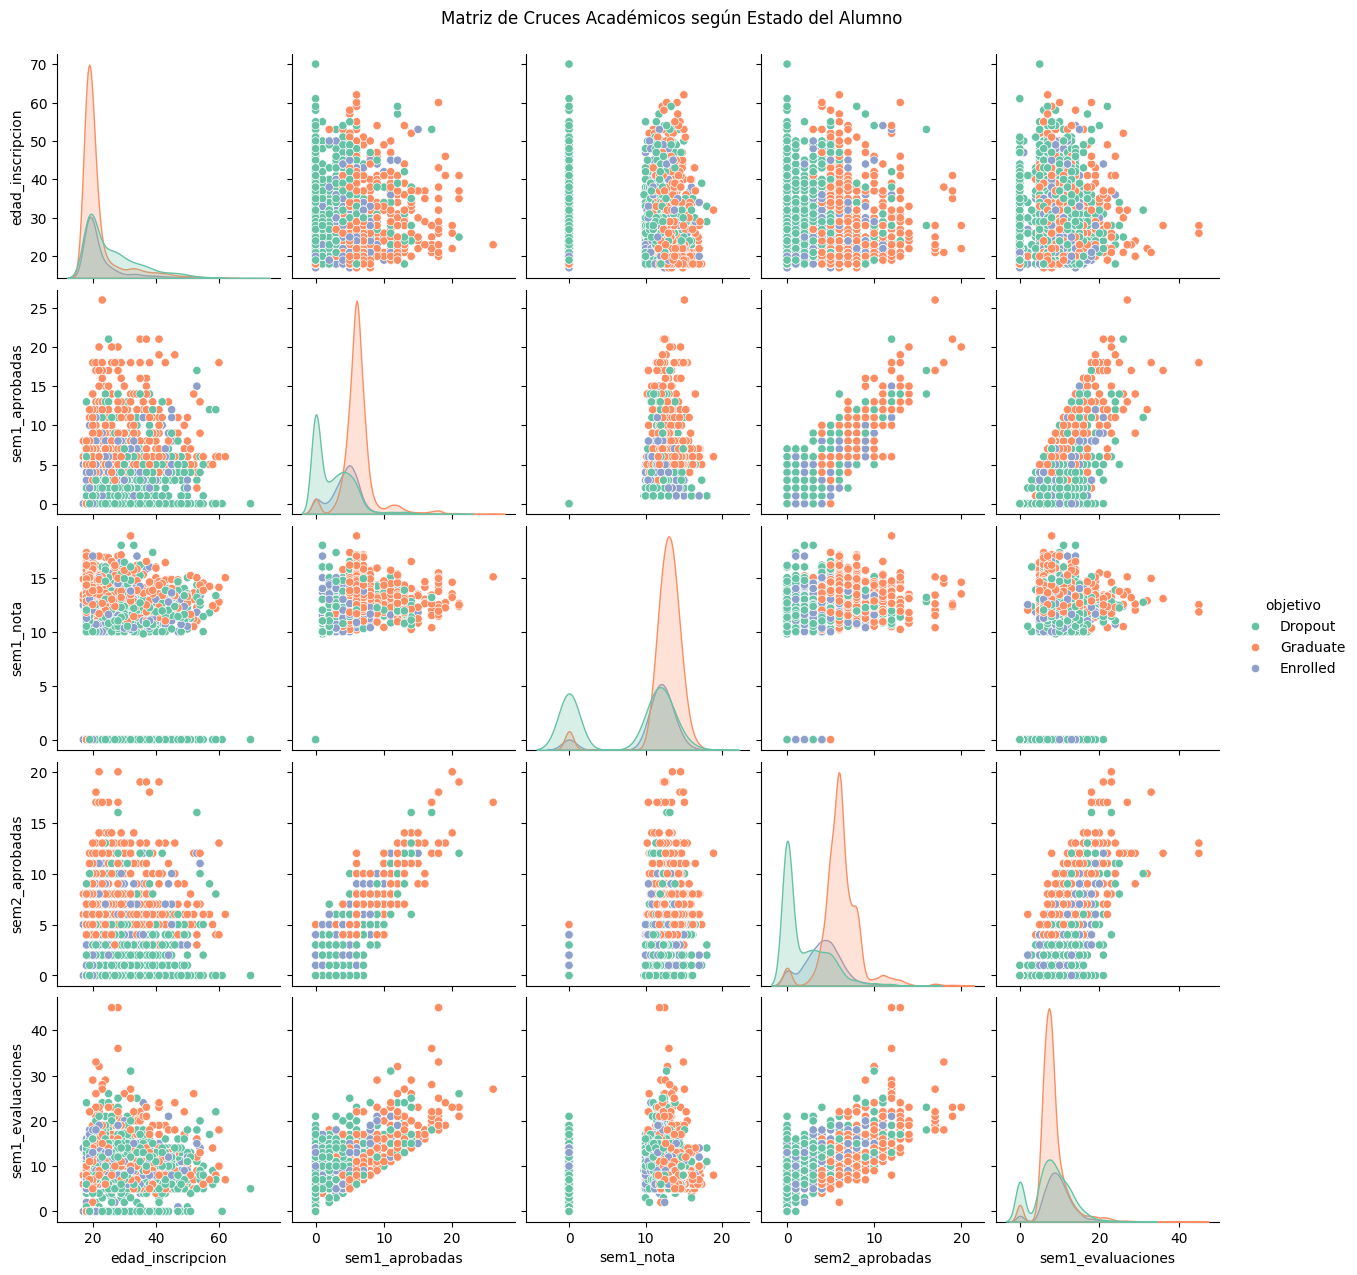

In [ ]:
#  PAIRPLOT
vars_graficar = [
    "edad_inscripcion",
    "sem1_aprobadas",
    "sem1_nota",
    "sem2_aprobadas",
    "sem1_evaluaciones"
]

sns.pairplot(
    df[vars_graficar + [target]],
    hue=target,
    diag_kind="kde",
    palette="Set2",)

plt.suptitle("Matriz de Cruces Académicos según Estado del Alumno", y=1.02)
plt.show()


*Estos gráficos muestran que los grupos están bastante bien separados, sobre todo cuando se analizan variables ligadas al rendimiento del primer año. Esto indica que el problema tiene una buena capacidad de separación entre clases, lo cual apoya el uso de modelos de clasificación supervisada, ya que hay señales tempranas que permiten diferenciar entre estudiantes que continúan, se gradúan o abandonan.*

**Visualización de agrupamientos con t-SNE**

Para validar si nuestro dataset es apto para predecir la deserción, aplicamos t-SNE, una técnica  que reduce las más de 30 dimensiones de los estudiantes a un plano 2D en base a sus similitudes.

In [ ]:
# Separamos las variables predictoras (X) de la variable objetivo (y)
target = "objetivo"

X = df.drop(target, axis=1)
y = df[target]

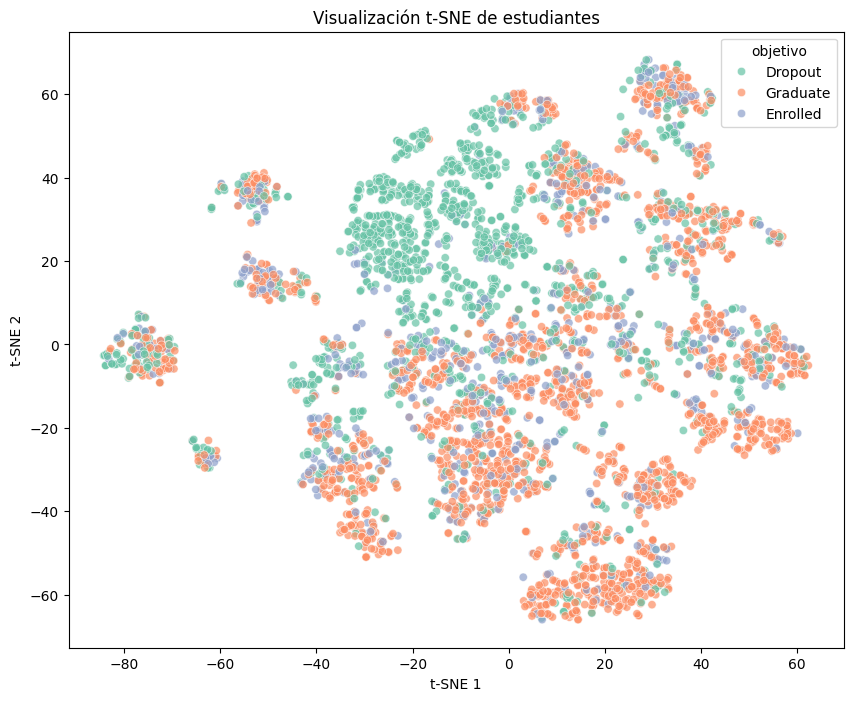

In [ ]:
#  Estandarizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2,perplexity=30,random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

# DataFrame para graficar
df_tsne = pd.DataFrame()

df_tsne["tSNE_1"] = X_tsne[:, 0]
df_tsne["tSNE_2"] = X_tsne[:, 1]
df_tsne[target] = y.values

# Gráfico
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df_tsne,x="tSNE_1",y="tSNE_2", hue=target,palette="Set2",alpha=0.7)

plt.title("Visualización t-SNE de estudiantes")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

*Como se puede observar en el gráfico, los estudiantes tienden a agruparse en zonas bastante definidas. En una región predominan los casos de abandono, mientras que en otra se concentran principalmente los estudiantes graduados. Esto indica que existen diferencias claras entre ambos grupos y que las variables analizadas logran capturar patrones importantes relacionados con la trayectoria académica.*


**Agrupamiento jerárquico de variables**

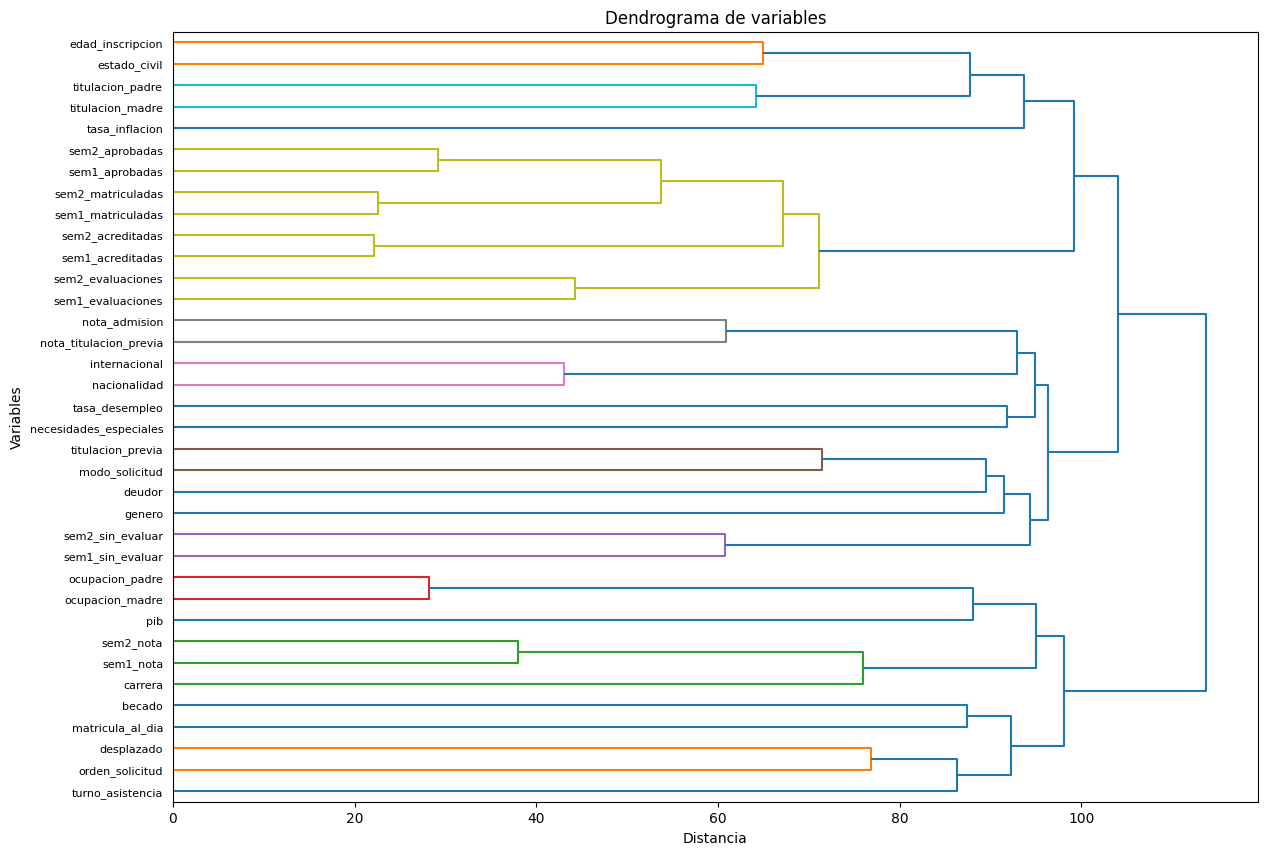

In [ ]:
# Variables numéricas
X = df.select_dtypes(include=["int64", "float64"])

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Matriz transpuesta
X_transpose = X_scaled.T

# Calcula similitudes entre variables
linked = linkage(X_transpose, method="complete")


# Dendrograma
plt.figure(figsize=(14, 10))
dendrogram(linked,labels=X.columns,leaf_rotation=0, orientation="right")

plt.title("Dendrograma de variables")
plt.xlabel("Distancia")
plt.ylabel("Variables")
plt.show()

# Maching Lerning

El objetivo prioritario es la detección temprana de alumnos en riesgo de abandono (clase Dropout) para permitir intervenciones institucionales oportunas. Dado el desbalance de los datos, el desempeño de los modelos de aprendizaje automático se evaluó de forma rigurosa mediante matrices de confusión, Recall y F1-Score, priorizando la maximización de capturas reales y la reducción de falsas alarmas.

## Preparación de los datos



Antes de entrenar los modelos de Machine Learning, preparamos el dataset para garantizar un correcto funcionamiento de los algoritmos y una evaluación adecuada del desempeño predictivo.

En primer lugar, separamos el conjunto de datos en:

* **Variables predictoras (X)** :contiene la información académica, demográfica y socioeconómica de los estudiantes,
* **Variable objetivo (y)**: correspondiente al estado final del estudiante (Dropout, Graduate o Enrolled).

In [ ]:
mapa_target = {
    'Dropout': 0,    # 0 para Abandono
    'Enrolled': 1,   # 1 para Cursando
    'Graduate': 2    # 2 para Graduado
}

# 2. Aplicamos el mapeo sobre la misma columna objetivo
df['objetivo'] = df['objetivo'].map(mapa_target)

In [ ]:
#df.info()

In [ ]:
X = df.drop("objetivo", axis=1)
y = df["objetivo"]

## División entrenamiento/prueba



Dividimos el dataset en:
* 80% para entrenamiento
* 20% para prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

## Escalado de variables



Se aplica un proceso de normalización/escalado utilizando StandardScaler.

Esto transforma las variables para que tengan:
* media cercana a 0,
* desviación estándar cercana a 1.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelos, entrenamiento y evaluación


### Naive Bayes

Trabaja con probabilidades puras basadas en el teorema de Bayes. Este modelo asume de forma "ingenua" que todas las características del estudiante (personales, académicas y socioeconómicas) son completamente independientes entre sí dado el estado final, sirviendo como un excelente punto de partida probabilístico.

 Reporte de Clasificación Detallado (Naive Bayes):
              precision    recall  f1-score   support

 0 (Dropout)       0.72      0.67      0.69       284
1 (Enrolled)       0.27      0.18      0.22       159
2 (Graduate)       0.70      0.83      0.76       442

    accuracy                           0.66       885
   macro avg       0.57      0.56      0.56       885
weighted avg       0.63      0.66      0.64       885



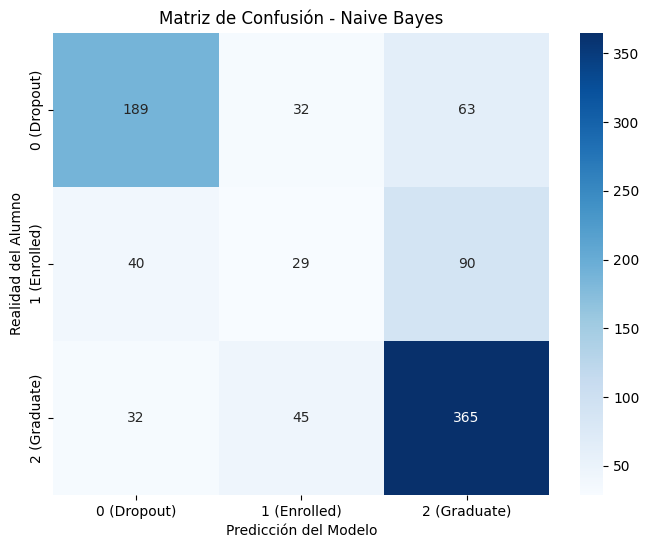

In [ ]:
#Creamos el modelo
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

#Ponemos a prueba al modelo
y_pred_nb = nb_model.predict(X_test_scaled)

#Cuadro detallado por categoría
print(" Reporte de Clasificación Detallado (Naive Bayes):")
nombres_clases = ['0 (Dropout)', '1 (Enrolled)', '2 (Graduate)']
print(classification_report(y_test, y_pred_nb, target_names=nombres_clases))

#Dibujamos la Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Naive Bayes')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Alumno')
plt.show()

### KNN (K-Nearest Neighbors)

Es un algoritmo basado en instancias y distancias métricas. Clasifica la trayectoria de un alumno analizando directamente a sus K "vecinos" más cercanos en el espacio multidimensional de características (por ejemplo, si la mayoría de sus vecinos geométricos abandonaron la carrera, el algoritmo asume que el estudiante replicará ese comportamiento).

Para elegir el mejor valor de $k$ en KNN, se evaluaron distintos números de vecinos mediante validación cruzada.

In [ ]:
#Definimos qué métrica queremos optimizar específicamente para la clase 0 (Dropout)
# Opción A: Optimizar el RECALL de la clase 0
#metrica_personalizada = make_scorer(recall_score, labels=[0], average='macro')

# Opción B : Optimizar el F1-SCORE de la clase 0
metrica_personalizada = make_scorer(f1_score, labels=[0], average='macro')

# Probamos K del 1 al 19 (impares)
param_grid = {
    'n_neighbors': list(range(1, 21, 2))
}

# Usamos cv=5 para validar en 5 pliegues cruzados
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring=metrica_personalizada,
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

#entrenar el GridSearch con los datos de entrenamiento
grid_search.fit(X_train_scaled, y_train)

#Extraer el mejor modelo y sus parámetros
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados: {'n_neighbors': 13}


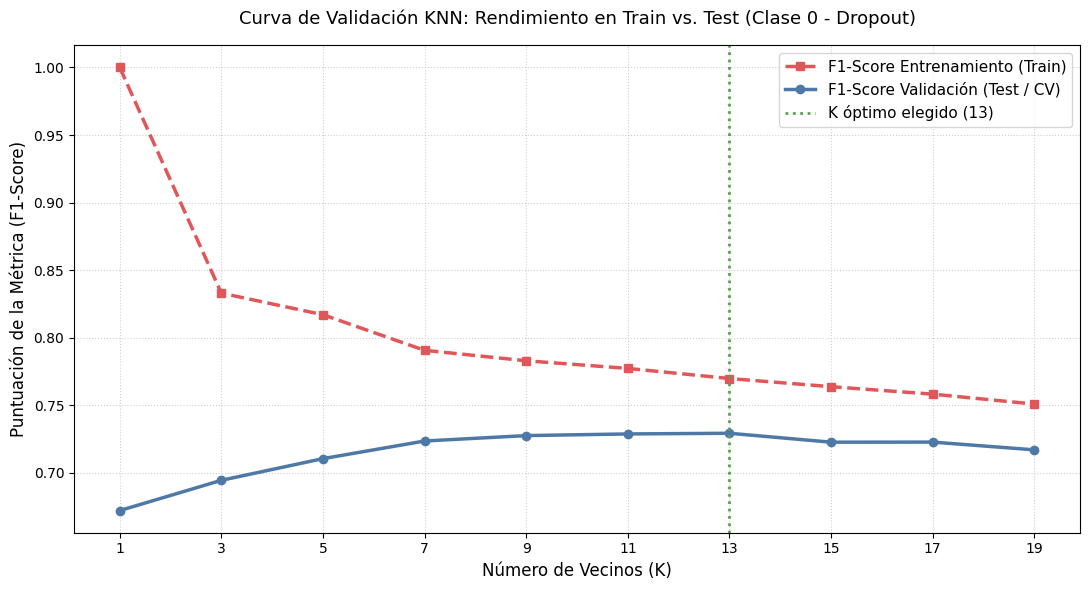

In [ ]:
resultados_df = pd.DataFrame(grid_search.cv_results_)

valores_k = resultados_df['param_n_neighbors']
puntuacion_train = resultados_df['mean_train_score']  # PuntuaciónTrain
puntuacion_test = resultados_df['mean_test_score']    # Puntuación de Validación (Test)

plt.figure(figsize=(11, 6))

# Dibujamos la línea de Entrenamiento (Train)
plt.plot(valores_k, puntuacion_train,
         marker='s', linewidth=2.5, linestyle='--', color='#e15759',
         label='F1-Score Entrenamiento (Train)')

# Dibujamos la línea de Validación (Test)
plt.plot(valores_k, puntuacion_test,
         marker='o', linewidth=2.5, color='#4e79a7',
         label='F1-Score Validación (Test / CV)')

# Resaltamos el K óptimo final elegido basado en el Test
mejor_k = grid_search.best_params_['n_neighbors']
mejor_score_test = grid_search.best_score_
plt.axvline(x=mejor_k, color='#59a14f', linestyle=':', linewidth=2,
            label=f'K óptimo elegido ({mejor_k})')

# Detalles estéticos de la gráfica
plt.title('Curva de Validación KNN: Rendimiento en Train vs. Test (Clase 0 - Dropout)', fontsize=13, pad=15)
plt.xlabel('Número de Vecinos (K)', fontsize=12)
plt.ylabel('Puntuación de la Métrica (F1-Score)', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='best')


plt.tight_layout()
plt.show()

Reporte de Clasificación Detallado (KNN vía GridSearchCV):
              precision    recall  f1-score   support

 0 (Dropout)       0.78      0.64      0.70       284
1 (Enrolled)       0.42      0.18      0.25       159
2 (Graduate)       0.69      0.92      0.79       442

    accuracy                           0.70       885
   macro avg       0.63      0.58      0.58       885
weighted avg       0.67      0.70      0.67       885



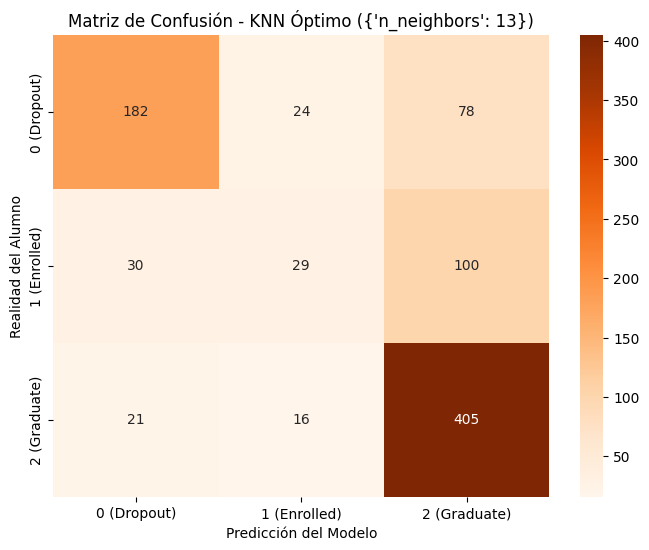

In [ ]:
knn_optimo = grid_search.best_estimator_

#Evaluar con el set de prueba (X_test_scaled)
y_pred_knn = knn_optimo.predict(X_test_scaled)

#Reporte
nombres_clases = ['0 (Dropout)', '1 (Enrolled)', '2 (Graduate)']
print("Reporte de Clasificación Detallado (KNN vía GridSearchCV):")
print(classification_report(y_test, y_pred_knn, target_names=nombres_clases))

#Matriz de Confusión
plt.figure(figsize=(8, 6))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.title(f"Matriz de Confusión - KNN Óptimo ({grid_search.best_params_})")
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Alumno')
plt.show()

###Regresión Logística (Logistic Regression)

Es un modelo estadístico tradicional que busca modelar la probabilidad de pertenencia a cada clase mediante una relación directa y lineal entre las variables de entrada, utilizando la función sigmoide para mapear los resultados.

In [ ]:
#Definimos la métrica enfocada en el F1-SCORE de la clase 0 (Dropout)
metrica_personalizada = make_scorer(f1_score, labels=[0], average='macro')

#Configurar la rejilla de parámetros para 'C'
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

#GridSearchCV para Regresión Logística
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring=metrica_personalizada,
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

#entrenar el GridSearch con los datos de entrenamiento
grid_search_lr.fit(X_train_scaled, y_train)

#Extraer el mejor modelo y sus parámetros
print("\nResultados de la Regresión Logística:")
print(f"Mejor parámetro 'C' encontrado: {grid_search_lr.best_params_['C']}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits

Resultados de la Regresión Logística:
Mejor parámetro 'C' encontrado: 0.01


Reporte de Clasificación Detallado (Regresión Logística Final):
              precision    recall  f1-score   support

 0 (Dropout)       0.82      0.76      0.79       284
1 (Enrolled)       0.51      0.25      0.33       159
2 (Graduate)       0.77      0.95      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.65      0.66       885
weighted avg       0.74      0.76      0.74       885



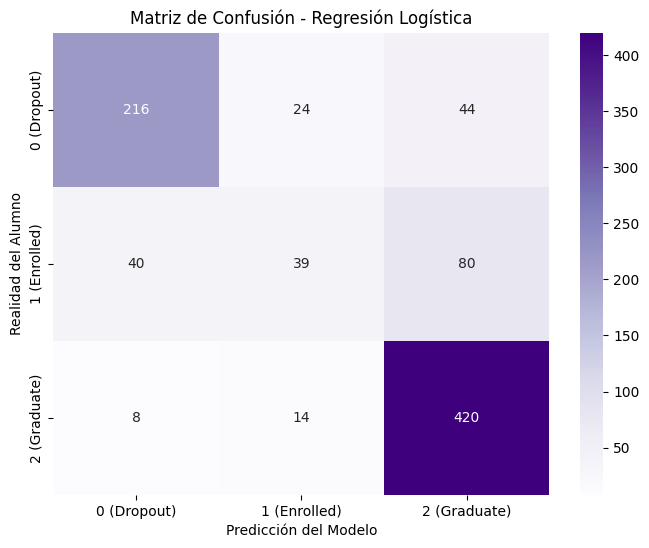

In [ ]:
lr_optimo = grid_search_lr.best_estimator_
y_pred_lr = lr_optimo.predict(X_test_scaled)

nombres_clases = ['0 (Dropout)', '1 (Enrolled)', '2 (Graduate)']
print("Reporte de Clasificación Detallado (Regresión Logística Final):")
print(classification_report(y_test, y_pred_lr, target_names=nombres_clases))

plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Alumno')
plt.show()

### Máquinas de Soporte Vectorial (SVM):

Este clasificador busca trazar una frontera de decisión óptima (hiperplano) en un espacio de altas dimensiones, intentando maximizar el margen de separación física entre las categorías de estudiantes. Al implementar un kernel RBF, permite proyectar los datos no lineales en dimensiones superiores para segmentar las clases más complejas.

Para  elegir las perillas implementamos GridSearchCV con Validación Cruzada. Así nos aseguramos de que el modelo elegido realmente sea el mejor y que no tenga overfitting (sobreentrenamiento).

In [ ]:
#Optimizamos el F1-SCORE de la clase 0 (Dropout)
metrica_personalizada = make_scorer(f1_score, labels=[0], average='macro')

param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    }
]

#GridSearchCV
grid_svm_completo = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring=metrica_personalizada,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

#Entrenar con los datos
grid_svm_completo.fit(X_train_scaled, y_train)

#mejores hiperparámetros basados en el F1-Score de la clase 0
print(f"Mejor KERNEL encontrado: {grid_svm_completo.best_params_['kernel'].upper()}")
print(f"Mejor C encontrado: {grid_svm_completo.best_params_['C']}")
if 'gamma' in grid_svm_completo.best_params_:
    print(f"Mejor GAMMA encontrado: {grid_svm_completo.best_params_['gamma']}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Ganadores absolutos de SVM:
Mejor KERNEL encontrado: RBF
Mejor C encontrado: 10
Mejor GAMMA encontrado: 0.01


Reporte de CLarificación (SVM Optimizado)
              precision    recall  f1-score   support

 0 (Dropout)       0.79      0.73      0.76       284
1 (Enrolled)       0.49      0.38      0.43       159
2 (Graduate)       0.79      0.89      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.67       885
weighted avg       0.74      0.75      0.74       885



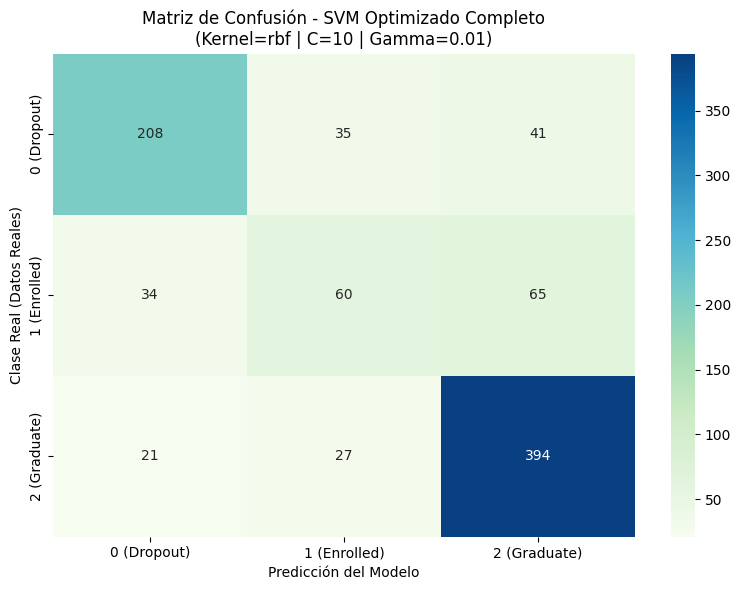

In [ ]:
#Evaluar el rendimiento real con el set de prueba
best_svm_completo = grid_svm_completo.best_estimator_
y_pred_svm_completo = best_svm_completo.predict(X_test_scaled)

# Reporte de Clasificación Final
nombres_clases = ['0 (Dropout)', '1 (Enrolled)', '2 (Graduate)']
print("Reporte de CLarificación (SVM Optimizado)")
print(classification_report(y_test, y_pred_svm_completo, target_names=nombres_clases))

#Graficar la Matriz de Confusión Estilizada
plt.figure(figsize=(8, 6))
cm_completo = confusion_matrix(y_test, y_pred_svm_completo, labels=best_svm_completo.classes_)

sns.heatmap(
    cm_completo,
    annot=True,
    fmt="d",
    cmap="GnBu",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)

kernel_ganador = grid_svm_completo.best_params_['kernel']
c_ganador = grid_svm_completo.best_params_['C']
gamma_ganador = grid_svm_completo.best_params_.get('gamma', 'N/A')

plt.title(f"Matriz de Confusión - SVM Optimizado Completo\n(Kernel={kernel_ganador} | C={c_ganador} | Gamma={gamma_ganador})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Datos Reales)")
plt.tight_layout()
plt.show()

### Árbol de Decision

 Construye de forma jerárquica un conjunto de reglas lógicas secuenciales basadas en umbrales de variables (ej. *¿Materias aprobadas < 5? Sí/No $\rightarrow$ ¿Tiene beca? Sí/No*), ofreciendo una alta interpretabilidad institucional.

In [ ]:
#Optimizamos el F1-SCORE de la clase 0 (Dropout)
metrica_personalizada = make_scorer(f1_score, labels=[0], average='macro')

param_grid = {
    'criterion': ['gini', 'entropy'],  # Evalúa ambas fórmulas matemáticas
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20]
}
# GridSearchCV para el Árbol de Decisión
# Añadimos class_weight='balanced' para proteger el Recall de la clase minoritaria
grid_search_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring=metrica_personalizada,
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

#Entrenar el GridSearch con los datos de entrenamiento
grid_search_tree.fit(X_train_scaled, y_train)

#Extraer el mejor modelo y sus parámetros
print("\n Resultados del Árbol de Decisión:")
print(f"Mejores parámetros: {grid_search_tree.best_params_}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

 Resultados del Árbol de Decisión:
Mejores parámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}


Reporte de Clasificación Detallado (Árbol de Decisión Final):
              precision    recall  f1-score   support

 0 (Dropout)       0.84      0.61      0.70       284
1 (Enrolled)       0.38      0.60      0.46       159
2 (Graduate)       0.81      0.79      0.80       442

    accuracy                           0.69       885
   macro avg       0.68      0.66      0.66       885
weighted avg       0.74      0.69      0.71       885



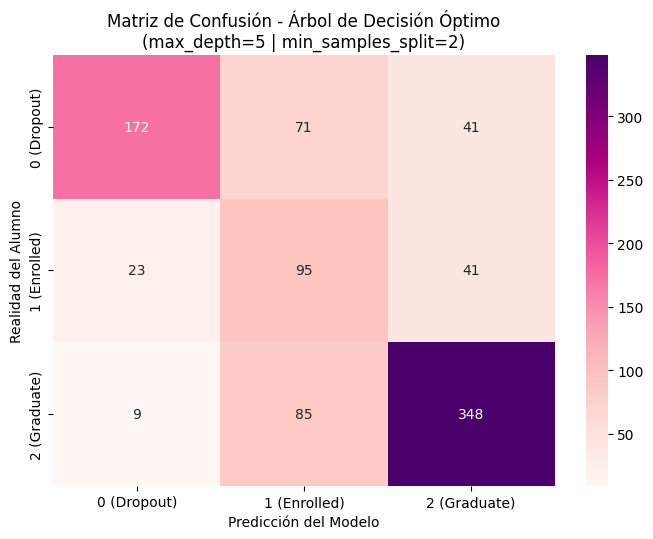

In [ ]:
tree_optimo = grid_search_tree.best_estimator_
y_pred_tree = tree_optimo.predict(X_test_scaled)

nombres_clases = ['0 (Dropout)', '1 (Enrolled)', '2 (Graduate)']
print("Reporte de Clasificación Detallado (Árbol de Decisión Final):")
print(classification_report(y_test, y_pred_tree, target_names=nombres_clases))


plt.figure(figsize=(7, 5.5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='RdPu', xticklabels=nombres_clases, yticklabels=nombres_clases)
mejor_depth = grid_search_tree.best_params_['max_depth']
plt.title(f"Matriz de Confusión - Árbol de Decisión Óptimo\n(max_depth={mejor_depth} | min_samples_split={grid_search_tree.best_params_['min_samples_split']})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Realidad del Alumno")
plt.tight_layout()
plt.show()

### Random Forest

Un solo **Árbol de Decisión** puede ser inestable y sobreentrenarse fácil. Para solucionar esto, usamos Random Forest, que crea un bosque de muchos árboles independientes . Mediante una técnica llamada **Bagging**, cada árbol se entrena con una porción de datos distinta y un grupo de variables al azar.

Cuando llega un alumno nuevo, cada árbol vota si es Dropout, Enrolled o Graduate. La categoría que junte más votos de todo el bosque es la predicción final. Esto hace que el modelo sea súper robusto y reduzca el error drásticamente.

In [ ]:
#Optimizamos el F1-SCORE de la clase 0 (Dropout)
metrica_personalizada = make_scorer(f1_score, labels=[0], average='macro')

# Evaluamos cantidad de árboles, profundidades y criterios de pureza
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 8, 12, None],
    'criterion': ['gini', 'entropy']
}

#GridSearchCV para Random Forest
# Usamos class_weight='balanced' para darle superpoderes frente al desbalance
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring=metrica_personalizada,
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

# 4. Entrenar el GridSearch con los datos de entrenamiento
print("Iniciando el entrenamiento del Bosque Aleatorio...")
grid_search_rf.fit(X_train_scaled, y_train)

# 5. Extraer el mejor modelo y sus parámetros
print("\n Resultados del Random Forest:")
print(f"Mejores parámetros: {grid_search_rf.best_params_}")


Iniciando el entrenamiento del Bosque Aleatorio...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Resultados del Random Forest:
Mejores parámetros: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 50}


Reporte de Clasificación Detallado (Random Forest Final):
              precision    recall  f1-score   support

 0 (Dropout)       0.83      0.75      0.79       284
1 (Enrolled)       0.53      0.35      0.42       159
2 (Graduate)       0.78      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.75      0.77      0.75       885



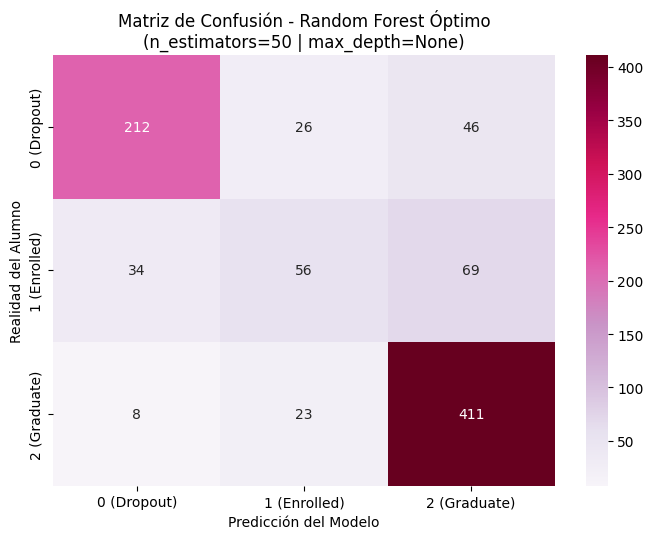

In [ ]:
rf_optimo = grid_search_rf.best_estimator_
y_pred_rf = rf_optimo.predict(X_test_scaled)

nombres_clases = ['0 (Dropout)', '1 (Enrolled)', '2 (Graduate)']
print("Reporte de Clasificación Detallado (Random Forest Final):")
print(classification_report(y_test, y_pred_rf, target_names=nombres_clases))

# 8. Matriz de Confusión Estilizada con la paleta rosa elegante "PuRd"
plt.figure(figsize=(7, 5.5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='PuRd', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title(f"Matriz de Confusión - Random Forest Óptimo\n(n_estimators={grid_search_rf.best_params_['n_estimators']} | max_depth={grid_search_rf.best_params_['max_depth']})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Realidad del Alumno")
plt.tight_layout()
plt.show()

# Conclusión

Debido al desbalance del dataset, la métrica Accuracy no resulta representativa del rendimiento real de los modelos, ya que puede dar una visión engañosa sobre su capacidad para detectar estudiantes en riesgo de abandono. Por este motivo, se priorizaron métricas más adecuadas para el problema, principalmente el Recall y el F1-Score de la clase Dropout.

Se dio especial importancia al Recall, ya que el objetivo principal es identificar la mayor cantidad posible de estudiantes que podrían abandonar. Sin embargo, optimizar solo esta métrica puede aumentar los falsos positivos.

Por esta razón, se utilizó el F1-Score como criterio de optimización, ya que permite equilibrar la detección de casos de abandono con un número razonable de falsas alarmas, logrando modelos más útiles en la práctica.

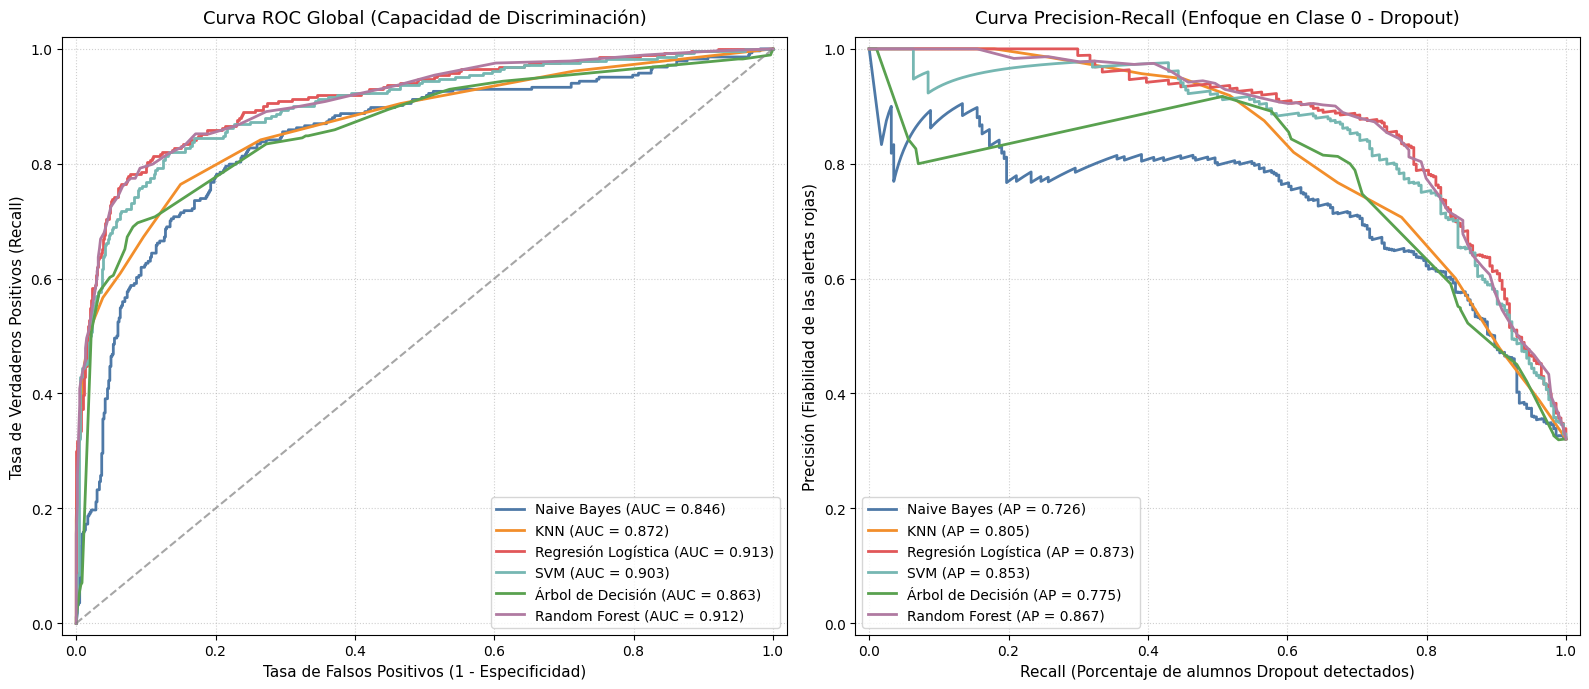

In [ ]:
diccionario_modelos = {
    'Naive Bayes': nb_model,
    'KNN': knn_optimo,
    'Regresión Logística': lr_optimo,
    'SVM': best_svm_completo,
    'Árbol de Decisión': tree_optimo,
    'Random Forest': rf_optimo
}

# Creamos la figura con dos submallas (lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Colores elegantes para que cada modelo tenga su identidad en ambas gráficas
colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#b07aa1']

for (nombre, modelo), color in zip(diccionario_modelos.items(), colores):

    # Obtener las probabilidades para la clase de riesgo (Dropout)
    try:
        if hasattr(modelo, "predict_proba"):
            y_prob = modelo.predict_proba(X_test_scaled)[:, 0] # Probabilidad de ser Clase 0 (Dropout)
        else:
            # Para SVM si se usó decision_function en lugar de predict_proba
            y_prob = -modelo.decision_function(X_test_scaled)


        # GRÁFICO 1: CURVA ROC
        # Para la curva ROC tradicional mapeamos si es clase 0 (1) o no (0)
        y_test_binario = (y_test == 0).astype(int)
        fpr, tpr, _ = roc_curve(y_test_binario, y_prob)
        roc_auc = auc(fpr, tpr)

        ax1.plot(fpr, tpr, color=color, lw=2,
                 label=f'{nombre} (AUC = {roc_auc:.3f})')

        # GRÁFICO 2: CURVA PRECISION-RECALL (PR)
        precision, recall, _ = precision_recall_curve(y_test_binario, y_prob)
        ap_score = average_precision_score(y_test_binario, y_prob)

        ax2.plot(recall, precision, color=color, lw=2,
                 label=f'{nombre} (AP = {ap_score:.3f})')

    except Exception as e:
        print(f"No se pudo graficar el modelo {nombre} debido a: {e}")

# Configuración estética de la Curva ROC
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7) # Línea aleatoria
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax1.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
ax1.set_title('Curva ROC Global (Capacidad de Discriminación)', fontsize=13, pad=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="lower right", fontsize=10)

# Configuración estética de la Curva Precision-Recall
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])
ax2.set_xlabel('Recall (Porcentaje de alumnos Dropout detectados)', fontsize=11)
ax2.set_ylabel('Precisión (Fiabilidad de las alertas rojas)', fontsize=11)
ax2.set_title('Curva Precision-Recall (Enfoque en Clase 0 - Dropout)', fontsize=13, pad=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.show()